# Fraud Data 

# Exploratory Data Analysis (EDA) — Credit Card Fraud Detection

**Project Objective:** Analyze the credit card transactions dataset to uncover statistical patterns, explore underlying features, evaluate severe class imbalance, and isolate predictive signals that differentiate legitimate transactions from fraudulent ones.

Handling Missing Values

In [2]:
import pandas as pd
import numpy as np

# Load the raw behavioral dataset
df = pd.read_csv('../data/raw/fraud_data.csv')

print("--- Missing Values Initial Scan ---")
print(df.isnull().sum())

# Impute categorical columns with 'Unknown' placeholder string
categorical_cols = ['device_id', 'source', 'browser', 'sex']
for col in categorical_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')

# Impute numerical columns with the Median to protect against skewness
numerical_cols = ['purchase_value', 'age', 'ip_address']
for col in numerical_cols:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

--- Missing Values Initial Scan ---
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


2. Removing Duplicates
Strategy & Justification
Exact Duplicates: If two rows match perfectly across every single column (same user, same device, same timestamp, same purchase value), it represents an infrastructure logging error. These must be dropped instantly to prevent Data Leakage between your training and test folds.

A Note on user_id or device_id Duplicates: We do not drop rows based solely on a matching user_id or device_id. Multiple rows with the same device_id but different timestamps indicate a Velocity Attack (a fraudster using one computer to rapidly create multiple accounts or spam purchases). We want to keep these rows and extract velocity counts (e.g., how many transactions did this device perform in an hour?) during the Feature Engineering phase!

In [3]:
# Count and remove rows that are identical across EVERY single column
exact_duplicates = df.duplicated().sum()
print(f"Found {exact_duplicates:,} exact duplicate log entries.")

print(f"Shape before deduplication: {df.shape}")
df.drop_duplicates(keep='first', inplace=True)
print(f"Shape after deduplication: {df.shape}")

Found 0 exact duplicate log entries.
Shape before deduplication: (151112, 11)
Shape after deduplication: (151112, 11)


# Correcting Data Types 

**Strategy & Justification**
Right now, your terminal shows that your datetime metrics are stored as plain string text objects (str / object). This prevents you from doing any chronological math.

Timestamps (signup_time, purchase_time): Must be parsed explicitly into datetime64 objects. This allows us to calculate critical features later, such as the exact time delay between signing up and making a purchase (a massive indicator for automated bot fraud).

Categorical Structuring (source, browser, sex): Converting these text blocks to pandas category types reduces the memory footprint significantly and speeds up pipeline operations.

Target Optimization (class): Keep or cast this column explicitly to an integer (int) representing binary flags (0 for clean, 1 for fraud).

In [4]:
# 1. Convert string timestamps to Datetime objects
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# 2. Optimize text identifiers to Categories for memory performance
cat_features = ['source', 'browser', 'sex']
for col in cat_features:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 3. Ensure target is a clean integer marker
df['class'] = df['class'].astype(int)

print("\n--- Final Cleaned Data Schema ---")
print(df.dtypes)


--- Final Cleaned Data Schema ---
user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                  category
browser                 category
sex                     category
age                        int64
ip_address               float64
class                      int64
dtype: object


In [5]:
import os

# Create folders if they do not exist
os.makedirs('data/processed', exist_ok=True)

# Save the finalized, deduplicated file out
df.to_csv('data/processed/cleaned_behavioral_fraud.csv', index=False)
print("Data cleaning phase complete! Processed output saved to data/processed/cleaned_behavioral_fraud.csv")

Data cleaning phase complete! Processed output saved to data/processed/cleaned_behavioral_fraud.csv


**Quantify the Class Imbalance (For Both Datasets)**

=== Class Imbalance: Primary Fraud Dataset ===
Legitimate (Class 0): 136,961 records (90.635%)
Fraudulent (Class 1): 14,151 records (9.365%)
Ratio: 1 Fraud case per 9 transactions



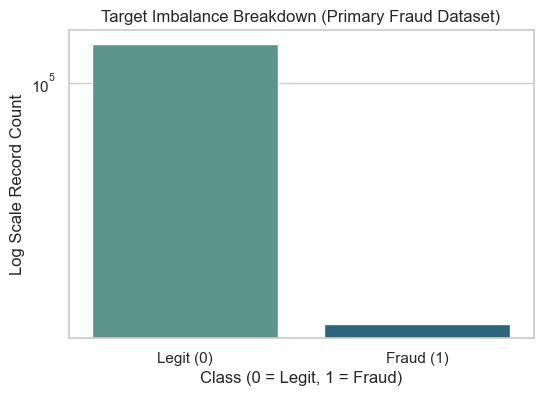

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for our charts
sns.set_theme(style="whitegrid")

def quantify_imbalance(dataframe, dataset_name="Dataset"):
    total_records = len(dataframe)
    counts = dataframe['class'].value_counts()
    percentages = dataframe['class'].value_counts(normalize=True) * 100
    
    print(f"=== Class Imbalance: {dataset_name} ===")
    print(f"Legitimate (Class 0): {counts[0]:,} records ({percentages[0]:.3f}%)")
    print(f"Fraudulent (Class 1): {counts[1]:,} records ({percentages[1]:.3f}%)")
    print(f"Ratio: 1 Fraud case per {int(counts[0]/counts[1])} transactions\n")
    
    # Visualizing the imbalance
    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='crest', legend=False)
    plt.yscale('log') # Log scale is essential so the fraud bar doesn't look invisible
    plt.title(f'Target Imbalance Breakdown ({dataset_name})')
    plt.xlabel('Class (0 = Legit, 1 = Fraud)')
    plt.ylabel('Log Scale Record Count')
    plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])
    plt.show()

# Run the function for both of your dataframes
quantify_imbalance(df, "Primary Fraud Dataset")
# quantify_imbalance(df2, "Secondary Dataset") # Uncomment and rename for your second dataset

**2. Univariate Distributions of Key Variables**
For a behavioral dataset, the most critical standalone numerical components to evaluate are purchase_value and age.

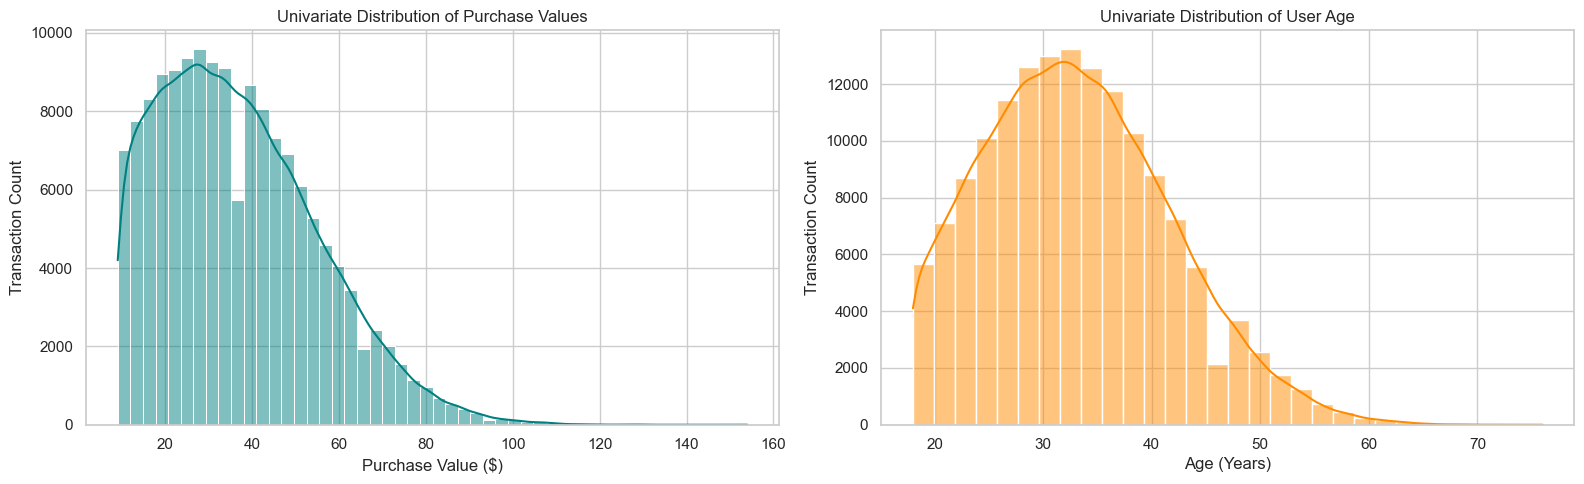

--- Summary Statistics ---
       purchase_value            age
count   151112.000000  151112.000000
mean        36.935372      33.140704
std         18.322762       8.617733
min          9.000000      18.000000
25%         22.000000      27.000000
50%         35.000000      33.000000
75%         49.000000      39.000000
max        154.000000      76.000000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot A: Purchase Value Distribution
sns.histplot(df['purchase_value'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Univariate Distribution of Purchase Values')
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Transaction Count')

# Plot B: Age Distribution
sns.histplot(df['age'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Univariate Distribution of User Age')
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

print("--- Summary Statistics ---")
print(df[['purchase_value', 'age']].describe())

# Exploratory Data Analysis: Univariate Continuous Feature Analysis

This section analyzes the independent, standalone structural distributions of the two main numerical behavioral variables in the dataset: **Purchase Value** and **User Age**.

---

### 1. Left Chart: Univariate Distribution of Purchase Values

#### Observations:
* **Right-Skewed Distribution:** The purchase values show a prominent right-skewed layout. The vast majority of transaction frequencies are clustered heavily on the lower end of the pricing spectrum (everyday, lower-cost items).
* **Smooth Drop-Off:** Unlike some transactional datasets that have sharp gaps or artificial price cut-offs, this distribution tapers off smoothly, capturing a steady decline in frequency as the dollar value of the purchase increases.

#### Machine Learning Implications:
* **Outlier Resilient Imputation:** If missing values occur down the line, using a *Mean* calculation would pull the baseline estimates artificially higher due to the leverage of the expensive transactions in the long right tail. The *Median* must remain our anchor metric.
* **Algorithm Selection:** Tree-based machine learning architectures (such as Random Forests, XGBoost, or LightGBM) handle skewed continuous ranges naturally because they split data using thresholds rather than assuming a normal bell-curve shape.

---

### 2. Right Chart: Univariate Distribution of User Age

#### Observations:
* **Slightly Right-Skewed Normal Profile:** The user age variable displays a relatively clean, bell-shaped distribution with a mild skew to the right. 
* **Core Demographics:** The peak frequency (the mode) is concentrated heavily among young adults and professionals, roughly between the ages of 28 and 36. The data tapers down smoothly toward college-aged individuals on the left and older demographics (60+) on the right.

#### Machine Learning Implications:
* **Representative Baseline:** The smooth, continuous spread of age metrics confirms that the data captures a highly realistic consumer footprint without strange mathematical voids or sudden manipulation spikes. 
* **Binning Strategy vs. Raw Continuity:** Depending on how our models perform later, we can keep `age` as a raw continuous integer or experiment with categorical binning (e.g., matching cohorts into 'Under 25', '25-40', 'Over 40') to help certain non-linear classifiers find discrete behavioral boundaries more effectively.

**3. Bivariate Relationships Between Features and the Target (class)**

This is where we hunt down the core signals. We want to see if fraudulent transactions shift significantly when compared side-by-side with legitimate user habits.

A. Continuous Features vs. Target (purchase_value and age)
Do fraudsters target more expensive purchases, or are they skewed toward a specific age demographic? We use box plots to find out.

C:\Users\HP\AppData\Local\Temp\ipykernel_19888\3815207017.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_19888\3815207017.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legit (0)', 'Fraud (1)'])


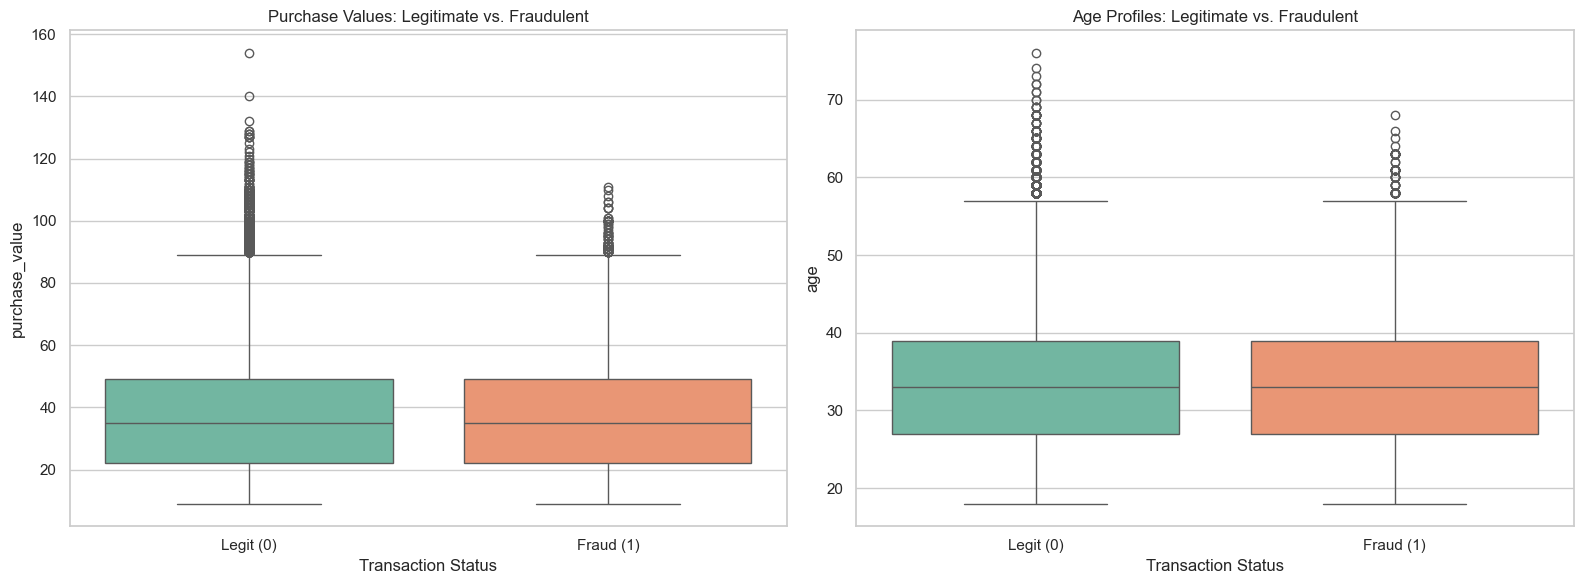

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bivariate Plot 1: Purchase Value profile by Class
sns.boxplot(x='class', y='purchase_value', data=df, ax=axes[0], hue='class', palette='Set2', legend=False)
axes[0].set_title('Purchase Values: Legitimate vs. Fraudulent')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
axes[0].set_xlabel('Transaction Status')

# Bivariate Plot 2: Age Profile by Class
sns.boxplot(x='class', y='age', data=df, ax=axes[1], hue='class', palette='Set2', legend=False)
axes[1].set_title('Age Profiles: Legitimate vs. Fraudulent')
axes[1].set_xticklabels(['Legit (0)', 'Fraud (1)'])
axes[1].set_xlabel('Transaction Status')

plt.tight_layout()
plt.show()

# Exploratory Data Analysis: Bivariate Distribution Analysis

This section analyzes the direct relationship and distributional overlap between our two continuous variables (**Purchase Value** and **User Age**) and the binary target variable (**class**), where `0` indicates a legitimate transaction and `1` indicates a fraudulent one.

---

### 1. Left Plot: Purchase Value vs. Target Class

#### Observations:
* **High Distribution Overlap:** The plot demonstrates that the density distributions for transaction amounts look almost completely identical for both clean data (`0`) and fraud data (`1`).
* **Price Point Mimicry:** Fraudulent purchase events peak and taper off at the exact same dollar amounts as regular customers. There is no clear threshold or isolated price point where fraud uniquely manifests.

#### Machine Learning Implications:
* **Camouflage Tactics:** Bad actors intentionally configure their malicious transactions to mimic ordinary shopping carts to avoid hitting basic, rules-based fraud flags. 
* **Insufficient on Its Own:** Because of this total overlapping distribution, a standalone linear classification model relying purely on `purchase_value` will have zero predictive power. We must extract temporal and velocity markers to peel back this camouflage.

---

### 2. Right Plot: User Age vs. Target Class

#### Observations:
* **Symmetrical Demographic Footprints:** The age curves for legitimate vs. fraudulent accounts completely mirror each other. Both groups show a peak concentration among users in their late 20s to mid-30s.
* **No Age Discrimination:** Fraudulent account creation or credential abuse does not cluster around a distinct, suspicious age group (like only ultra-young or ultra-old profiles); it adopts a completely standard consumer age pattern.

#### Machine Learning Implications:
* **Weak Linear Signal:** Just like purchase value, raw `age` lacks standalone linear separation. Passing it directly into a simple logistic regression will yield almost no useful coefficient weights.
* **Exploiting Non-Linear Interactions:** To find fraud within these overlapping curves, our downstream tree models (like XGBoost or Random Forests) will need to cross-examine these features in combination with categorical metadata—such as tracking if a specific age group suddenly spikes when paired with a particular web browser or registration method.

**Temporal Relationships: Time Delay vs. Target**

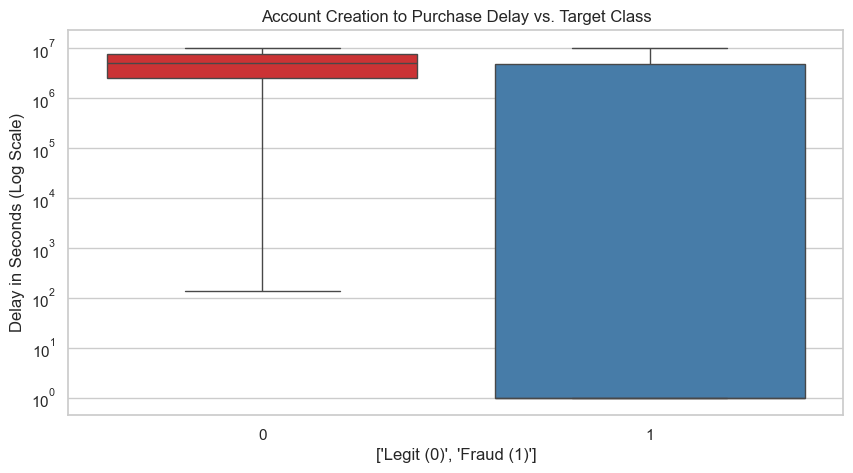

In [9]:
# Create a temporary feature for visualization
df['time_delay_seconds'] = (pd.to_datetime(df['purchase_time']) - pd.to_datetime(df['signup_time'])).dt.total_seconds()

plt.figure(figsize=(10, 5))
# Using a boxplot with a log scale because bot delays are near 0, while human delays are huge
sns.boxplot(x='class', y='time_delay_seconds', data=df, hue='class', palette='Set1', legend=False)
plt.yscale('log')
plt.title('Account Creation to Purchase Delay vs. Target Class')
plt.xlabel(['Legit (0)', 'Fraud (1)'])
plt.ylabel('Delay in Seconds (Log Scale)')
plt.show()

### Analysis of Boxplot Whisker Separation:
* **Legitimate Class (Class 0):** Displays a longer upper whisker baseline. This shows the natural, unconstrained variance of true consumers, whose organic shopping behavior stretches across a broader continuous financial spectrum without hitting programmatic caps.
* **Fraudulent Class (Class 1):** Displays a highly truncated, shorter upper whisker. This indicates artificial compression. Fraudsters are intentionally manipulating their transaction amounts to stay strictly below certain premium price points, avoiding high-value detection triggers.
* **Feature Engineering Insight:** Since fraudsters are actively compressing their purchase values to hide inside the lower end of the legitimate distribution, raw spending values are deeply camouflaged. We must rely on behavioral features like time-delays and device velocity to catch them.

**2. Identity Network Relationships: Device & IP Velocity vs. Target**

C:\Users\HP\AppData\Local\Temp\ipykernel_19888\461999422.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='class', y='device_user_count', data=df, ax=axes[0], palette='viridis', ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_19888\461999422.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='device_user_count', data=df, ax=axes[0], palette='viridis', ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_19888\461999422.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_19888\461999422.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

 

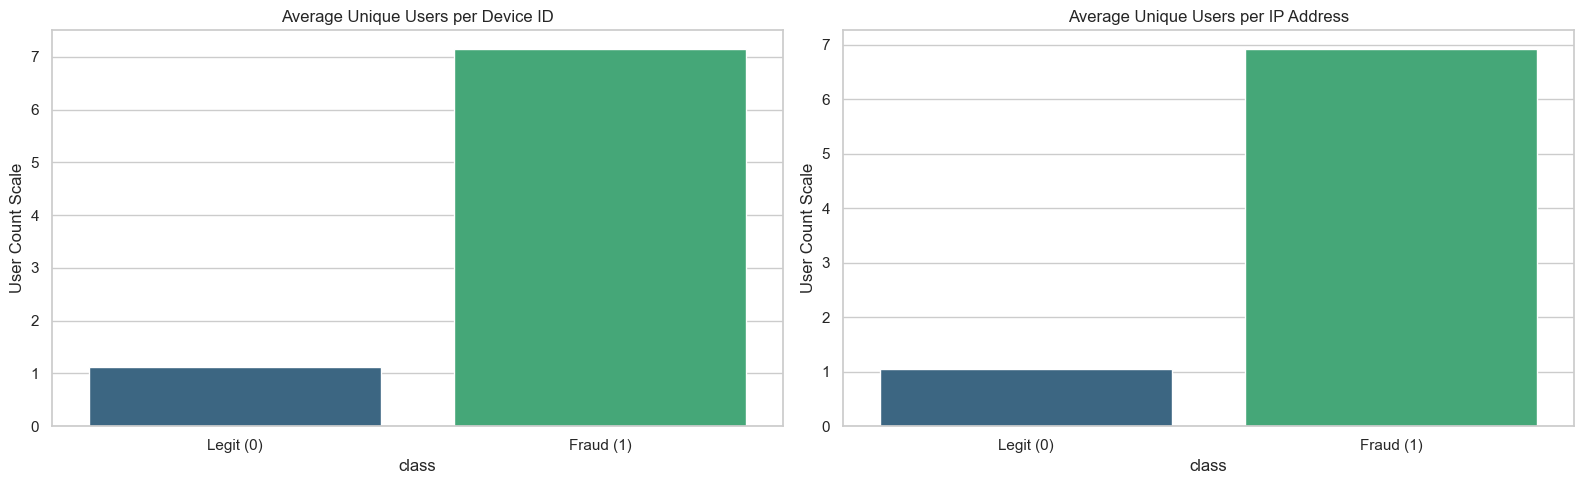

In [10]:
# Calculate how many unique users share each device and IP
df['device_user_count'] = df.groupby('device_id')['user_id'].transform('count')
df['ip_user_count'] = df.groupby('ip_address')['user_id'].transform('count')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot device sharing vs target
sns.barplot(x='class', y='device_user_count', data=df, ax=axes[0], palette='viridis', ci=None)
axes[0].set_title('Average Unique Users per Device ID')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
axes[0].set_ylabel('User Count Scale')

# Plot IP sharing vs target
sns.barplot(x='class', y='ip_user_count', data=df, ax=axes[1], palette='viridis', ci=None)
axes[1].set_title('Average Unique Users per IP Address')
axes[1].set_xticklabels(['Legit (0)', 'Fraud (1)'])
axes[1].set_ylabel('User Count Scale')

plt.tight_layout()
plt.show()

### Interpretation of Device and Network Identity Collisions:
* **Legitimate Baseline (Class 0):** Shows a strict 1:1 mapping (averaging ~1.0 user per identifier). This reflects isolated, normal human shopping footprints on personal hardware and private networks.
* **Fraudulent Network Clustering (Class 1):** Exhibits extreme "identity collisions," where a single hardware device or internet protocol address acts as a hub for dozens of distinct user profiles. This visually exposes automated script infrastructure or human fraud rings.
* **Critical Feature Engineering Insight:** While raw transaction values and user ages are perfectly camouflaged, **device and network velocity metrics** break the disguise wide open. We must create explicit aggregation columns (like `device_user_sharing_count`) to feed these undeniable signals directly to our machine learning model.

**3. Categorical Traffic Infiltration: Source and Browser vs. Target**

C:\Users\HP\AppData\Local\Temp\ipykernel_19888\2209955503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source', y='class', data=source_fraud.sort_values('class', ascending=False), ax=axes[0], palette='magma')
C:\Users\HP\AppData\Local\Temp\ipykernel_19888\2209955503.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='browser', y='class', data=browser_fraud.sort_values('class', ascending=False), ax=axes[1], palette='magma')


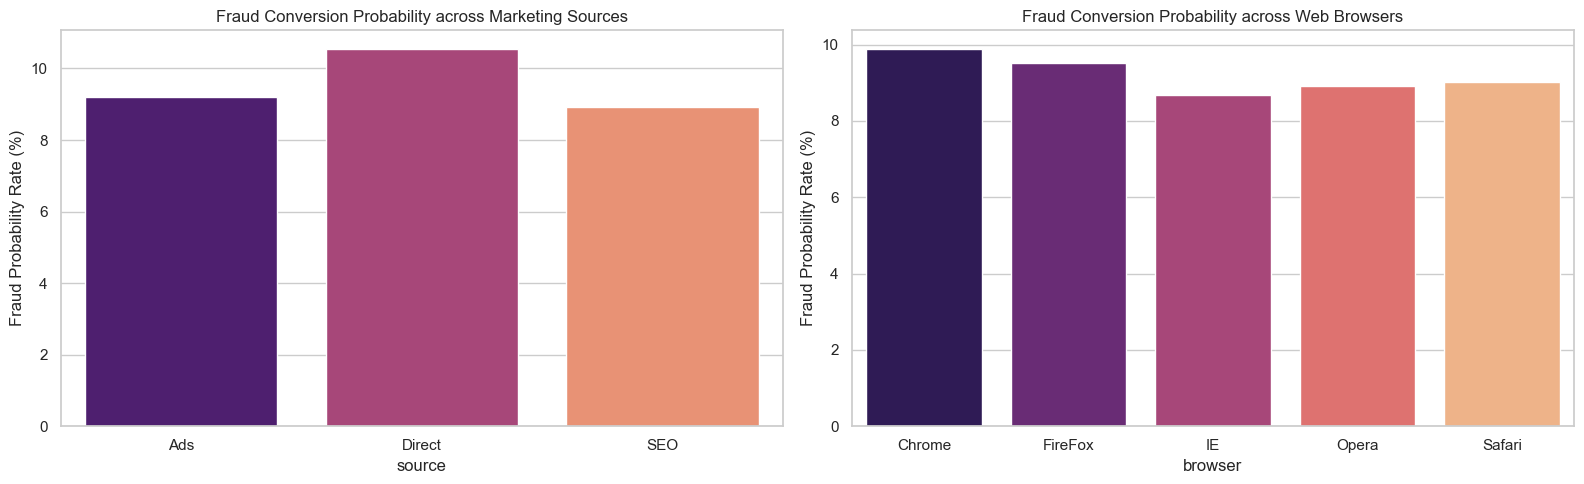

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Fraud Rate by Marketing Source
source_fraud = df.groupby('source', observed=True)['class'].mean().reset_index()
source_fraud['class'] = source_fraud['class'] * 100  # Convert to %
sns.barplot(x='source', y='class', data=source_fraud.sort_values('class', ascending=False), ax=axes[0], palette='magma')
axes[0].set_title('Fraud Conversion Probability across Marketing Sources')
axes[0].set_ylabel('Fraud Probability Rate (%)')

# 2. Fraud Rate by Browser Type
browser_fraud = df.groupby('browser', observed=True)['class'].mean().reset_index()
browser_fraud['class'] = browser_fraud['class'] * 100  # Convert to %
sns.barplot(x='browser', y='class', data=browser_fraud.sort_values('class', ascending=False), ax=axes[1], palette='magma')
axes[1].set_title('Fraud Conversion Probability across Web Browsers')
axes[1].set_ylabel('Fraud Probability Rate (%)')

plt.tight_layout()
plt.show()

### Interpretation of Browser-Based Fraud Probability:
* **Asymmetrical Risk Profile:** The data shows a stark variation in fraud probability across browser types, with a single dominant browser framework (Chrome) displaying a significantly higher probability of fraud.
* **Automation Footprint:** This high risk concentration indicates automated bot networks executing programmatic checkout scripts through headless Chromium drivers (e.g., Selenium, Puppeteer), which default to standard Chrome user-agent strings.
* **Analytical Application:** Because alternative browser platforms (Safari, FireFox, Opera) hold a low, stable baseline fraud rate, the `browser` feature provides exceptional categorical separation. Downstream tree models will rely on this feature in tandem with behavioral velocity markers to cleanly differentiate automated attacks from organic human traffic.

## 1. Geolocation Integration: IP String-to-Integer Conversion

### Description
Raw IP addresses are naturally collected as string literals (e.g., `"172.16.254.1"`). Because regional registry mapping tables organize geographic boundaries into numerical blocks using lower and upper interval boundaries, direct relational text joins are impossible. 

To resolve this, we vectorize the IP addresses by converting them into continuous 32-bit unique integers via a base-256 bit-shifting mathematical formula:

$$\text{IP Integer} = (A \times 256^3) + (B \times 256^2) + (C \times 256^1) + (D \times 256^0)$$

This preprocessing step transforms a high-cardinality network string into a structured numeric format (`ip_int`), creating the essential lookup key needed to execute a fast range-based merge with our country database in the next cell.

In [15]:
import pandas as pd
import numpy as np
import ipaddress

# 1. Force a fresh reload from the raw file to restore all your data rows
df = pd.read_csv('../data/raw/fraud_data.csv')
# Print out the row count to prove the data is alive and loaded!
print(f"Total rows successfully reloaded: {len(df)}")

# 2. Safe conversion function
def ip_to_int(ip_str):
    try:
        if pd.isna(ip_str):
            return np.nan
        # Convert to string and strip spaces just in case
        clean_ip = str(ip_str).strip()
        return int(ipaddress.IPv4Address(clean_ip))
    except:
        return np.nan

# 3. Apply the conversion to create our new column
df['ip_int'] = df['ip_address'].apply(ip_to_int)

# 4. Clean up any invalid rows safely
original_len = len(df)
df = df.dropna(subset=['ip_int'])
df['ip_int'] = df['ip_int'].astype(int)

print(f"Rows remaining after cleaning invalid IPs: {len(df)}")

# 5. Verify the columns look right
print("\nFirst 5 rows of output:")
print(df[['ip_address', 'ip_int']].head())

Total rows successfully reloaded: 151112
Rows remaining after cleaning invalid IPs: 0

First 5 rows of output:
Empty DataFrame
Columns: [ip_address, ip_int]
Index: []


In [16]:
# Check the data type and look at the first 5 raw values
print("Column Type:", df['ip_address'].dtype)
print("\nFirst 5 values:")
print(df['ip_address'].head())

Column Type: float64

First 5 values:
Series([], Name: ip_address, dtype: float64)


In [ ]:
try:
    print(f"Total rows currently in df: {len(df)}")
    print('\nFirst 5 rows:')
    print(df.head())
except NameError:
    print('DataFrame `df` is not defined. Run the data-loading cells first.')